In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../raw/news/media-bias-scrubbed-results.csv")
df.head(10)

,site_name,url,bias_rating,factual_reporting_rating
0,(The) Interpreter Magazine,http://www.interpretermag.com/,-8,HIGH
1,1600 Daily,https://www.whitehouse.gov/1600daily,26,MIXED
2,2ndVote,https://2ndvote.com/,29,MIXED
3,680 News,http://www.680news.com/,-3,HIGH
4,71 Republic,https://71republic.com/,15,HIGH
5,9 News (Australia),http://www.9news.com.au/,6,HIGH
6,ABC News Australia,http://www.abc.net.au/news/,-4,HIGH
7,ABC News,http://abcnews.go.com/,-13,HIGH
8,ABC11 Eyewitness News,http://abc11.com/,-11,HIGH
9,Above the Law,http://abovethelaw.com/,-9,HIGH


In [3]:
df.drop_duplicates('site_name')

,site_name,url,bias_rating,factual_reporting_rating
0,(The) Interpreter Magazine,http://www.interpretermag.com/,-8,HIGH
1,1600 Daily,https://www.whitehouse.gov/1600daily,26,MIXED
2,2ndVote,https://2ndvote.com/,29,MIXED
3,680 News,http://www.680news.com/,-3,HIGH
4,71 Republic,https://71republic.com/,15,HIGH
...,...,...,...,...
1599,Young Conservatives,http://www.youngcons.com/,30,MIXED
1600,Your Black World,http://yourblackworld.net,-22,MIXED
1601,Youth Radio,https://youthradio.org/,-10,HIGH
1602,Z Magazine,https://zcomm.org/zmag/,-22,HIGH


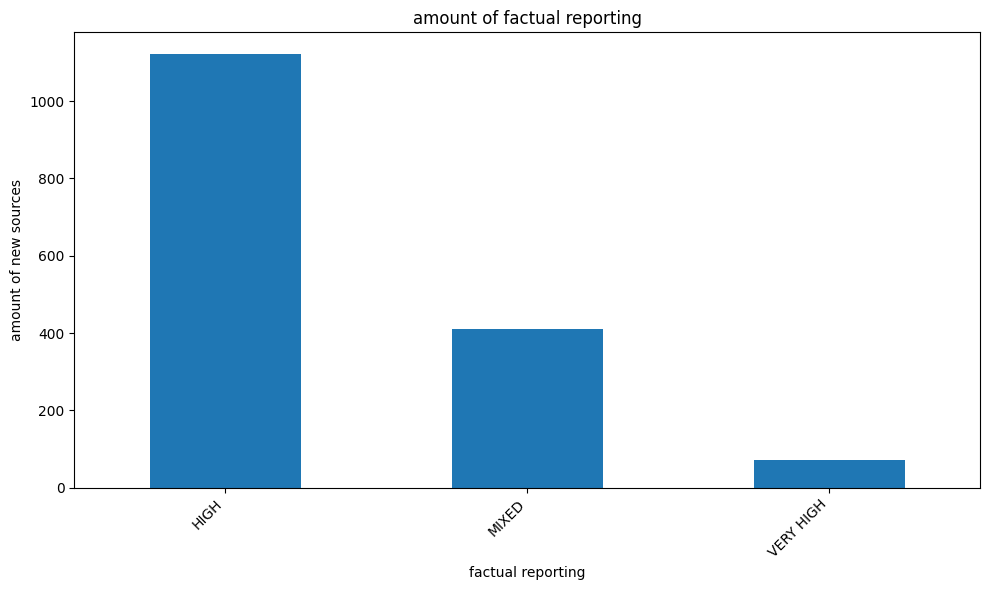

In [4]:
import matplotlib.pyplot as plt

section_counts = df['factual_reporting_rating'].value_counts()

plt.figure(figsize=(10, 6))
section_counts.plot(kind='bar')
plt.title('amount of factual reporting')
plt.xlabel('factual reporting')
plt.ylabel('amount of new sources')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
df['bias_rating'].unique()

array([ -8,  26,  29,  -3,  15,   6,  -4, -13, -11,  -9,  -5,  24,  28,
        30, -26, -25, -22, -10, -15,  -2, -12,  -1,  13,   1, -28,   2,
       -16, -23,  14,   9,  21,  10,  22,  27, -18,  19, -21,  16, -14,
        -7,  12,  11,   3, -19, -17, -27,  23,   0,   7, -30, -29,   8,
        17, -20, -24,   5,  20, -33])

In [6]:
def classify_bias(score):
    if score < -10:
        return 'Far Left'
    elif score < -3:
        return 'Left'
    elif score <= 3:
        return 'Center'
    elif score <= 10:
        return 'Right'
    else:
        return 'Far Right'

df['bias_label'] = df['bias_rating'].apply(classify_bias)

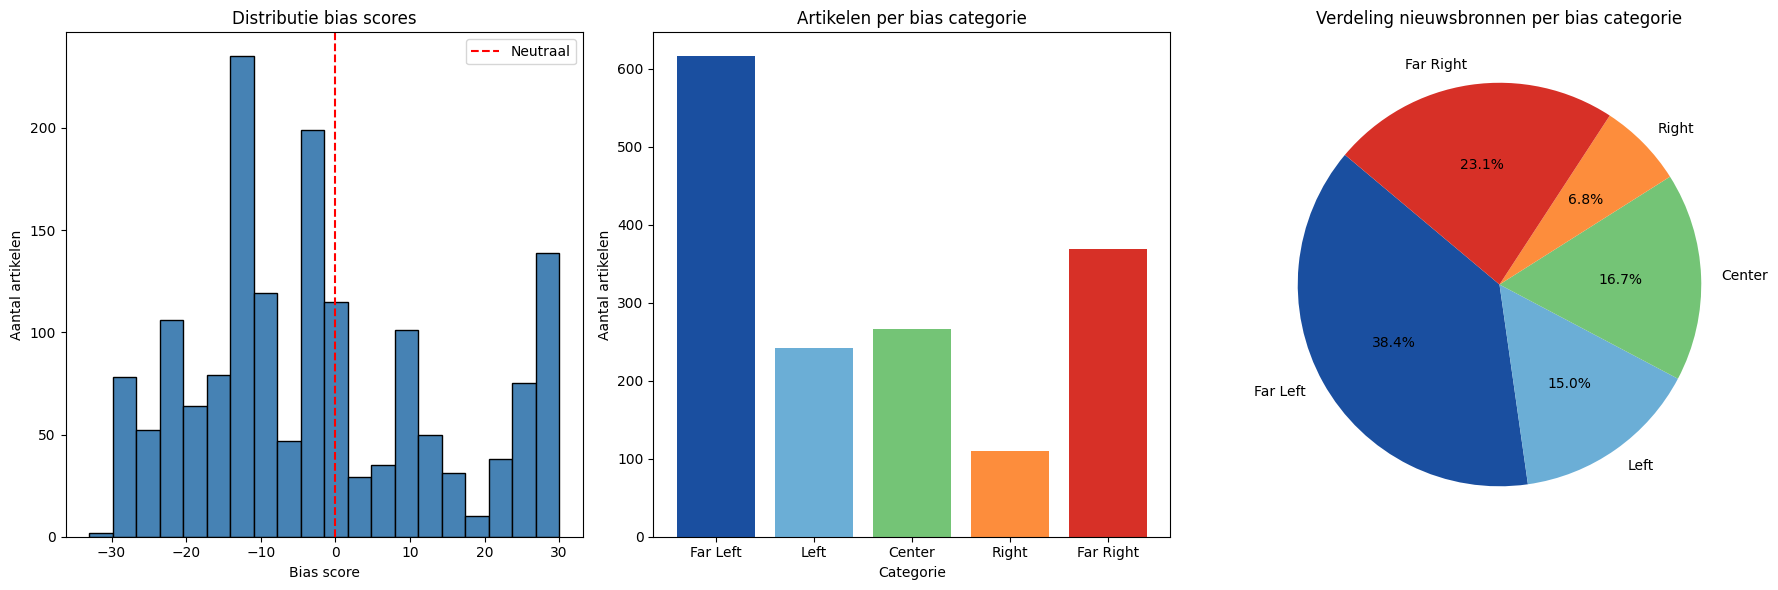

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram van ruwe scores
axes[0].hist(df['bias_rating'], bins=20, color='steelblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', label='Neutraal')
axes[0].set_title('Distributie bias scores')
axes[0].set_xlabel('Bias score')
axes[0].set_ylabel('Aantal artikelen')
axes[0].legend()

# Bar chart van categorieën
order = ['Far Left', 'Left', 'Center', 'Right', 'Far Right']
colors = ['#1a4fa0', '#6baed6', '#74c476', '#fd8d3c', '#d73027']
counts = df['bias_label'].value_counts().reindex(order)
axes[1].bar(counts.index, counts.values, color=colors)
axes[1].set_title('Artikelen per bias categorie')
axes[1].set_xlabel('Categorie')
axes[1].set_ylabel('Aantal artikelen')

# Pie chart van sites per bias categorie
site_bias = df.groupby('site_name')['bias_label'].first()
site_counts = site_bias.value_counts().reindex(order)
axes[2].pie(site_counts, labels=site_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[2].set_title('Verdeling nieuwsbronnen per bias categorie')

plt.tight_layout()
plt.show()

In [8]:
df.columns

Index(['site_name', 'url', 'bias_rating', 'factual_reporting_rating',
       'bias_label'],
      dtype='str')

In [9]:
df.drop(columns=['url', 'bias_rating'],inplace=True)
df.head(1)

,site_name,factual_reporting_rating,bias_label
0,(The) Interpreter Magazine,HIGH,Left
